In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
'/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv'

'/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv'

In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv.zip')
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [6]:
print(df.shape)
print(df.columns)
df.info()

(549346, 2)
Index(['URL', 'Label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [7]:
!unzip -o "/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv.zip" -d "/content/drive/MyDrive/Phishing_Detection/"

Archive:  /content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv.zip
  inflating: /content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv  


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv')
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


1. Import library

In [9]:
!pip install -q nltk wordcloud

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import nltk

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from nltk.tokenize import RegexpTokenizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.pipeline import make_pipeline
from wordcloud import WordCloud

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

2. Read file csv

In [11]:
df = pd.read_csv('/content/drive/MyDrive/Phishing_Detection/phishing_site_urls.csv')
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


3. Check the label

In [12]:
print(df.shape)
print(df.columns)
print(df['Label'].value_counts())

(549346, 2)
Index(['URL', 'Label'], dtype='object')
Label
good    392924
bad     156422
Name: count, dtype: int64


4. Create variables input and output

In [13]:
X = df['URL'].astype(str)
y = df['Label'].astype(str)

5. Split training/testing set

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(439476,) (109870,)


6. Vector url

In [15]:
cv = CountVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=5000)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

print(X_train_cv.shape, X_test_cv.shape)

(439476, 5000) (109870, 5000)


In [16]:
!pip install wordcloud
!pip install selenium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # Common alias for plotly
import time
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline

from nltk.tokenize import RegexpTokenizer
from nltk.stem.snowball import SnowballStemmer

from PIL import Image
from wordcloud import WordCloud
from bs4 import BeautifulSoup

import selenium # You might need to import specific components like webdriver for practical use
import networkx as nx # Common alias for networkx
import re
import urllib.parse

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [17]:
print("\nLabel distribution:")
print(df['Label'].value_counts())


Label distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


In [18]:
df.isnull().sum()

,0
URL,0
Label,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [20]:
df.tail()

,URL,Label
549341,23.227.196.215/,bad
549342,apple-checker.org/,bad
549343,apple-iclods.org/,bad
549344,apple-uptoday.org/,bad
549345,apple-search.info,bad


/tmp/ipykernel_991/2694512560.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Label', data=df, palette={'bad': 'red','good': 'green'})


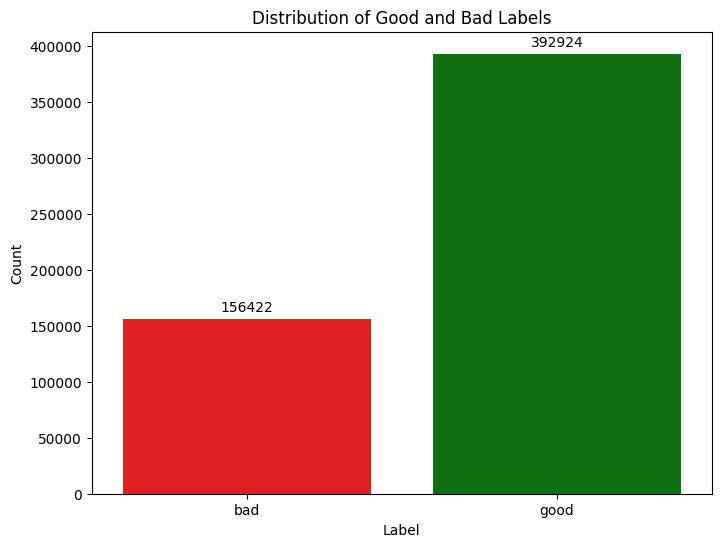

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Ensure your dataframe is named 'df' and has a 'Label' column
# Example dummy data (remove this line if you already have your data loaded)
# df = pd.DataFrame({'Label': ['good']*25000 + ['bad']*25050})

plt.figure(figsize=(8, 6))

# Create the plot
# Note: Using hue=Label with x=Label is redundant but fine.
# We set dodge=False so the bars align properly if hue is used this way.
ax = sns.countplot(x='Label', data=df, palette={'bad': 'red','good': 'green'})

plt.title('Distribution of Good and Bad Labels')
plt.xlabel('Label')
plt.ylabel('Count')

# Add count labels on top of the bars
# We check if bar_label exists (Matplotlib 3.4+)
try:
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', color='black', padding=3)
except AttributeError:
    # Fallback for older Matplotlib versions (manual text placement)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

plt.savefig('goodbadlabel.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('goodbadlabel.png')

In [22]:
print("\nLabel distribution:")
print(df['Label'].value_counts())


Label distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


In [23]:
df.isnull().sum()

,0
URL,0
Label,0


In [24]:
df['URL'] = df['URL'].str.replace(r'^www\.', '', regex=True)
display(df.head())

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [25]:
df.head(100)

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad
...,...,...
95,rsaxena.5gbfree.com/facebook.html,bad
96,steamcommunity-giveaway.my3gb.com,bad
97,steamglfts.h16.ru,bad
98,steamglfts.hut2.ru/,bad


URLs parsed into components and stored in 'parsed_url' column.

In [26]:
import urllib.parse

def parse_url_components(url):
    if not re.match(r'^[a-zA-Z]+://', url):
        url = url
    try:
        return urllib.parse.urlparse(url)
    except ValueError:
        # Handle cases where urllib.parse.urlparse fails (e.g., malformed IPv6 in hostname)
        # Return a default ParseResult object to avoid crashing and allow subsequent operations
        return urllib.parse.ParseResult(scheme='', netloc='', path='', params='', query='', fragment='')

df['parsed_url'] = df['URL'].apply(parse_url_components)
print("URLs parsed into components and stored in 'parsed_url' column.")
display(df.head())

URLs parsed into components and stored in 'parsed_url' column.


,URL,Label,parsed_url
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737..."
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into...."
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid..."


'url_length' feature

In [27]:
def get_url_length(parsed_url):
    return len(parsed_url.geturl())

df['url_length'] = df['parsed_url'].apply(get_url_length)
print("Added 'url_length' feature.")
display(df.head())

Added 'url_length' feature.


,URL,Label,parsed_url,url_length
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116


In [28]:
def get_hostname_length(parsed_url):
    return len(parsed_url.netloc)

df['hostname_length'] = df['parsed_url'].apply(get_hostname_length)
print("Added 'hostname_length' feature.")
display(df.head())

Added 'hostname_length' feature.


,URL,Label,parsed_url,url_length,hostname_length
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0


In [29]:
def get_path_length(parsed_url):
    return len(parsed_url.path)

df['path_length'] = df['parsed_url'].apply(get_path_length)
print("Added 'path_length' feature.")
display(df.head())

Added 'path_length' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79


In [30]:
def count_dots_in_hostname(parsed_url):
    return parsed_url.netloc.count('.')

df['dots_in_hostname'] = df['parsed_url'].apply(count_dots_in_hostname)
print("Added 'dots_in_hostname' feature.")
display(df.head())

Added 'dots_in_hostname' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0


In [31]:
import re

def has_ip_address(parsed_url):
    # 1. Get the domain/host part
    hostname = parsed_url.netloc

    if not hostname:
        return 0

    # 2. Handle Port Numbers (e.g., '192.168.1.1:80' -> '192.168.1.1')
    # We split by ':' and take the first part
    hostname = hostname.split(':')[0]

    # --- PATTERNS ---

    # Standard IPv4: Matches 4 groups of digits (e.g., 23.227.196.215)
    ipv4_pattern = r'^(\d{1,3}\.){3}\d{1,3}$'

    # IPv6: Matches standard and compressed IPv6 (e.g., 2001:0db8::...)
    # This regex looks for colon-separated hex groups
    ipv6_pattern = r'^[\[]?([0-9a-fA-F]{1,4}:)+[0-9a-fA-F]{1,4}[\]]?$'

    # Hexadecimal IP: Matches obfuscated IPs (e.g., 0x58.0xCC.0xCA.0x62)
    # Phishers use this because browsers convert it to IP automatically
    hex_pattern = r'^(0x[0-9a-fA-F]+)(\.0x[0-9a-fA-F]+){3}$'

    # Integer IP: Matches single long numbers (e.g., http://2130706433)
    # Browsers interpret these as IPs (2130706433 = 127.0.0.1)
    integer_ip_pattern = r'^\d+$'

    # --- CHECKS ---

    if re.match(ipv4_pattern, hostname):
        return 1
    if re.match(ipv6_pattern, hostname):
        return 1
    if re.match(hex_pattern, hostname):
        return 1
    if re.match(integer_ip_pattern, hostname):
        return 1

    return 0

# Apply the function
df['has_ip_address'] = df['parsed_url'].apply(has_ip_address)

print("Feature 'has_ip_address' extracted successfully.")
display(df.head())

Feature 'has_ip_address' extracted successfully.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0


In [32]:
df.tail()

,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address
549341,23.227.196.215/,bad,"(, , 23.227.196.215/, , , )",15,0,15,0,0
549342,apple-checker.org/,bad,"(, , apple-checker.org/, , , )",18,0,18,0,0
549343,apple-iclods.org/,bad,"(, , apple-iclods.org/, , , )",17,0,17,0,0
549344,apple-uptoday.org/,bad,"(, , apple-uptoday.org/, , , )",18,0,18,0,0
549345,apple-search.info,bad,"(, , apple-search.info, , , )",17,0,17,0,0


In [33]:
def count_char(url, char):
    return url.count(char)

df['count_hyphens'] = df['URL'].apply(lambda x: count_char(x, '-'))
print("Added 'count_hyphens' feature.")
display(df.head())

Added 'count_hyphens' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1


In [34]:
def count_digits(url):
    return sum(c.isdigit() for c in url)

df['count_digits'] = df['URL'].apply(count_digits)
print("Added 'count_digits' feature.")
display(df.head())

Added 'count_digits' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21


In [35]:
def get_num_subdomains(parsed_url):
    hostname = parsed_url.netloc
    if hostname and '.' in hostname:
        # Split by dot and subtract 1 for the TLD
        # More robust approach might involve tldextract, but for now, simple count
        return hostname.count('.')
    return 0

df['num_subdomains'] = df['parsed_url'].apply(get_num_subdomains)
print("Added 'num_subdomains' feature.")
display(df.head())

Added 'num_subdomains' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,num_subdomains
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,0
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,0


In [36]:
!pip install tldextract
print("tldextract library installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.4 MB/s eta 0:00:00
tldextract library installed.


In [37]:
import tldextract

def get_tld(parsed_url):
    hostname = parsed_url.netloc
    if hostname:
        extracted = tldextract.extract(hostname)
        return extracted.suffix
    return ''

df['tld'] = df['parsed_url'].apply(get_tld)
print("Added 'tld' feature.")
display(df.head())

Added 'tld' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,num_subdomains,tld
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,0,
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,0,
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,0,
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,0,
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,0,


List (all_special_chars)

In [38]:
import string

def find_special_characters(url):
    special_chars = set()
    for char in url:
        # Check if the character is not alphanumeric, not a dot, is printable, and is not a whitespace character
        if not char.isalnum() and char != '.' and char.isprintable() and not char.isspace():
            special_chars.add(char)
    return special_chars

all_special_chars = set()
for url in df['URL']:
    all_special_chars.update(find_special_characters(url))

print("Unique *visible* special characters found in URLs (excluding '.', alphanumeric, and all whitespace/control characters):")
print(sorted(list(all_special_chars)))

Unique *visible* special characters found in URLs (excluding '.', alphanumeric, and all whitespace/control characters):
['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', '«', '¬', '®', '¯', '°', '±', '´', '¶', '·', '¸', '»', '¿', '×', '÷', '–', '—', '’', '‚', '“', '”', '•', '…', '‰', '€', '™']


Total unique special characters

In [39]:
print(f"Total unique special characters found: {len(all_special_chars)}")

Total unique special characters found: 65


In [40]:
def count_all_special_chars(url):
    count = 0
    for char in url:
        if not char.isalnum() and char != '.':
            count += 1
    return count

df['total_special_chars'] = df['URL'].apply(count_all_special_chars)
print("Added 'total_special_chars' feature.")
display(df.head())

Added 'total_special_chars' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,num_subdomains,tld,total_special_chars
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,0,,26
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,0,,10
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,0,,12
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,0,,2
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,0,,12


In [41]:
# The `count_char` function is already defined in cell `49a1c983`

# Sort the special characters to ensure consistent column order
sorted_special_chars = sorted(list(all_special_chars))

for char in sorted_special_chars:
    # Create a clean column name, replacing non-alphanumeric chars if necessary (e.g., for ' ')
    col_name = f"count_{char}"
    # For characters that might cause issues in column names (like ' ' or control chars),
    # we can replace them with a descriptive string if needed.
    # However, for typical visible special characters, direct use as 'count_!' is usually fine.
    # For ' ', we'll use 'count_space'
    if char == ' ':
        col_name = "count_space"

    df[col_name] = df['URL'].apply(lambda x: count_char(x, char))
    print(f"Added '{col_name}' feature.")

print("Finished adding all special character count features.")
display(df.head())

Added 'count_!' feature.
Added 'count_"' feature.
Added 'count_#' feature.
Added 'count_$' feature.
Added 'count_%' feature.
Added 'count_&' feature.
Added 'count_'' feature.
Added 'count_(' feature.
Added 'count_)' feature.
Added 'count_*' feature.
Added 'count_+' feature.
Added 'count_,' feature.
Added 'count_-' feature.
Added 'count_/' feature.
Added 'count_:' feature.
Added 'count_;' feature.
Added 'count_<' feature.
Added 'count_=' feature.
Added 'count_>' feature.
Added 'count_?' feature.
Added 'count_@' feature.
Added 'count_[' feature.
Added 'count_\' feature.
Added 'count_]' feature.
Added 'count_^' feature.
Added 'count__' feature.
Added 'count_`' feature.
Added 'count_{' feature.
Added 'count_|' feature.
Added 'count_}' feature.
Added 'count_~' feature.
Added 'count_¡' feature.
Added 'count_¢' feature.
Added 'count_£' feature.
Added 'count_¤' feature.
Added 'count_¥' feature.
Added 'count_¦' feature.
Added 'count_§' feature.
Added 'count_¨' feature.
Added 'count_©' feature.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_—,count_’,count_‚,count_“,count_”,count_•,count_…,count_‰,count_€,count_™
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,0,0,0,0
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,0,0,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,0,0,0,0
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,0,0,0,0


In [42]:
import nltk
nltk.download('punkt')
print("'punkt' NLTK data package downloaded.")

'punkt' NLTK data package downloaded.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [43]:
nltk.download('wordnet')
print("'wordnet' NLTK data package downloaded.")

'wordnet' NLTK data package downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...


In [44]:
bad_sites = df[df.Label == 'bad']
good_sites = df[df.Label == 'good']

In [45]:
# Function to generate character n-grams
def char_ngrams_tokenizer(text, n=3): # Using trigrams (n=3) as an example
    text = str(text) # Ensure text is string and convert to lowercase
    ngrams = []
    for i in range(len(text) - n + 1):
        ngrams.append(text[i:i+n])
    return ngrams

# Apply character-level N-gram tokenization to the 'URL' column
df['tokenized_url'] = df.URL.map(lambda t: char_ngrams_tokenizer(t))

print("URLs tokenized with character-level N-grams and 'tokenized_url' column updated.")
display(df.head())

URLs tokenized with character-level N-grams and 'tokenized_url' column updated.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_’,count_‚,count_“,count_”,count_•,count_…,count_‰,count_€,count_™,tokenized_url
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,0,0,0,"[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ..."
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,0,0,0,"[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,0,0,0,"[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ..."
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[mai, ail, il., l.p, .pr, pri, rin, int, nta, ..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,0,0,0,"[the, hew, ewh, whi, his, isk, ske, key, eyd, ..."


In [46]:
char_ngrams_tokenizer(df.URL[0])

['nob',
 'obe',
 'bel',
 'ell',
 'll.',
 'l.i',
 '.it',
 'it/',
 't/7',
 '/70',
 '70f',
 '0ff',
 'ffb',
 'fb5',
 'b52',
 '52d',
 '2d0',
 'd07',
 '079',
 '791',
 '910',
 '109',
 '09d',
 '9dc',
 'dca',
 'ca5',
 'a56',
 '566',
 '664',
 '64c',
 '4cc',
 'cce',
 'ce6',
 'e6f',
 '6f3',
 'f31',
 '317',
 '173',
 '737',
 '373',
 '737',
 '378',
 '782',
 '82/',
 '2/l',
 '/lo',
 'log',
 'ogi',
 'gin',
 'in.',
 'n.S',
 '.Sk',
 'Sky',
 'kyP',
 'yPe',
 'Pe.',
 'e.c',
 '.co',
 'com',
 'om/',
 'm/e',
 '/en',
 'en/',
 'n/c',
 '/cg',
 'cgi',
 'gi-',
 'i-b',
 '-bi',
 'bin',
 'in/',
 'n/v',
 '/ve',
 'ver',
 'eri',
 'rif',
 'ifi',
 'fic',
 'ica',
 'cat',
 'ati',
 'tio',
 'ion',
 'on/',
 'n/l',
 '/lo',
 'log',
 'ogi',
 'gin',
 'in/',
 'n/7',
 '/70',
 '70f',
 '0ff',
 'ffb',
 'fb5',
 'b52',
 '52d',
 '2d0',
 'd07',
 '079',
 '791',
 '910',
 '109',
 '09d',
 '9dc',
 'dca',
 'ca5',
 'a56',
 '566',
 '664',
 '64c',
 '4cc',
 'cce',
 'ce6',
 'e6f',
 '6f3',
 'f31',
 '317',
 '173',
 '737',
 '373',
 '73/',
 '3/i',
 '/in',


In [47]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# Get the English stop words list
stop_words = set(stopwords.words('english'))

# Apply the filtering logic directly using a lambda function
df['tokenized_url_no_stopwords'] = df['tokenized_url'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

print("Stop words removed from 'tokenized_url' and 'tokenized_url_no_stopwords' column added using lambda.")
display(df.head())

Stop words removed from 'tokenized_url' and 'tokenized_url_no_stopwords' column added using lambda.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_‚,count_“,count_”,count_•,count_…,count_‰,count_€,count_™,tokenized_url,tokenized_url_no_stopwords
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,0,0,"[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ..."
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,0,0,"[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,0,0,"[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ..."
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,0,0,"[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,0,0,"[the, hew, ewh, whi, his, isk, ske, key, eyd, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ..."


In [48]:
from nltk.stem import WordNetLemmatizer

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'tokenized_url' column using a lambda function
df['lemmatized_url'] = df['tokenized_url_no_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

print("URLs lemmatized and 'lemmatized_url' column added.")
display(df.head())

URLs lemmatized and 'lemmatized_url' column added.


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_“,count_”,count_•,count_…,count_‰,count_€,count_™,tokenized_url,tokenized_url_no_stopwords,lemmatized_url
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,0,"[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ..."
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,0,"[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,0,"[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, io, osb, sby, b..."
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,0,"[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,0,"[the, hew, ewh, whi, his, isk, ske, key, eyd, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ..."


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Join the lemmatized tokens back into a single string for TF-IDF (re-creating if necessary)
df['lemmatized_url_str'] = df['lemmatized_url'].apply(lambda x: ' '.join(x))

# Initialize TfidfVectorizer with specified parameters
tfidf_vectorizer_optimized = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, dtype=np.float32)

# Fit and transform the lemmatized URLs
tfidf_matrix_optimized = tfidf_vectorizer_optimized.fit_transform(df['lemmatized_url_str'])

print("TF-IDF Vectorization re-applied with max_features=20000 and dtype=np.float32.")
print(f"Shape of optimized TF-IDF matrix: {tfidf_matrix_optimized.shape}")

# Display feature names (sample)
feature_names_optimized = tfidf_vectorizer_optimized.get_feature_names_out()
print("Sample optimized TF-IDF features (unigrams and bigrams):")
print(feature_names_optimized[:10]) # Display first 10 feature names

display(df.head())

TF-IDF Vectorization re-applied with max_features=20000 and dtype=np.float32.
Shape of optimized TF-IDF matrix: (549346, 20000)
Sample optimized TF-IDF features (unigrams and bigrams):
['00' '00 00' '00 000' '00 001' '00 10' '00 at' '00 co' '00 ht' '000'
 '000 00']


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_”,count_•,count_…,count_‰,count_€,count_™,tokenized_url,tokenized_url_no_stopwords,lemmatized_url,lemmatized_url_str
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,"[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...",nob obe bel ell ll. l.i .it it/ t/7 /70 70f 0f...
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,"[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...",dgh ghj hjd jdg dgf gf. f.c .co com om/ m/p /p...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,"[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, io, osb, sby, b...",ser erv rvi vic ici cio io osb sby bys ys. s.c...
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,"[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...",mai ail il. l.p .pr pri rin int nta tak aki ki...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,"[the, hew, ewh, whi, his, isk, ske, key, eyd, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ...",hew ewh whi isk ske key eyd ydr dre reg egs gs...


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Join the lemmatized tokens back into a single string for TF-IDF (re-creating if necessary)
df['lemmatized_url_str'] = df['lemmatized_url'].apply(lambda x: ' '.join(x))

# Initialize TfidfVectorizer with specified parameters
tfidf_vectorizer_optimized = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, dtype=np.float32)

# Fit and transform the lemmatized URLs
tfidf_matrix_optimized = tfidf_vectorizer_optimized.fit_transform(df['lemmatized_url_str'])

print("TF-IDF Vectorization re-applied with max_features=20000 and dtype=np.float32.")
print(f"Shape of optimized TF-IDF matrix: {tfidf_matrix_optimized.shape}")

# Display feature names (sample)
feature_names_optimized = tfidf_vectorizer_optimized.get_feature_names_out()
print("Sample optimized TF-IDF features (unigrams and bigrams):")
print(feature_names_optimized[:10]) # Display first 10 feature names

display(df.head())

TF-IDF Vectorization re-applied with max_features=20000 and dtype=np.float32.
Shape of optimized TF-IDF matrix: (549346, 20000)
Sample optimized TF-IDF features (unigrams and bigrams):
['00' '00 00' '00 000' '00 001' '00 10' '00 at' '00 co' '00 ht' '000'
 '000 00']


,URL,Label,parsed_url,url_length,hostname_length,path_length,dots_in_hostname,has_ip_address,count_hyphens,count_digits,...,count_”,count_•,count_…,count_‰,count_€,count_™,tokenized_url,tokenized_url_no_stopwords,lemmatized_url,lemmatized_url_str
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"(, , nobell.it/70ffb52d079109dca5664cce6f31737...",225,0,134,0,0,4,58,...,0,0,0,0,0,0,"[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...","[nob, obe, bel, ell, ll., l.i, .it, it/, t/7, ...",nob obe bel ell ll. l.i .it it/ t/7 /70 70f 0f...
1,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,bad,"(, , dghjdgf.com/paypal.co.uk/cycgi-bin/webscr...",77,0,77,0,0,2,1,...,0,0,0,0,0,0,"[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...","[dgh, ghj, hjd, jdg, dgf, gf., f.c, .co, com, ...",dgh ghj hjd jdg dgf gf. f.c .co com om/ m/p /p...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"(, , serviciosbys.com/paypal.cgi.bin.get-into....",177,0,177,0,0,1,47,...,0,0,0,0,0,0,"[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, ios, osb, sby, ...","[ser, erv, rvi, vic, ici, cio, io, osb, sby, b...",ser erv rvi vic ici cio io osb sby bys ys. s.c...
3,mail.printakid.com/www.online.americanexpress....,bad,"(, , mail.printakid.com/www.online.americanexp...",60,0,60,0,0,0,0,...,0,0,0,0,0,0,"[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...","[mai, ail, il., l.p, .pr, pri, rin, int, nta, ...",mai ail il. l.p .pr pri rin int nta tak aki ki...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"(, , thewhiskeydregs.com/wp-content/themes/wid...",116,0,79,0,0,1,21,...,0,0,0,0,0,0,"[the, hew, ewh, whi, his, isk, ske, key, eyd, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ...","[hew, ewh, whi, isk, ske, key, eyd, ydr, dre, ...",hew ewh whi isk ske key eyd ydr dre reg egs gs...


Word clouds generated and displayed for bad and good URLs.

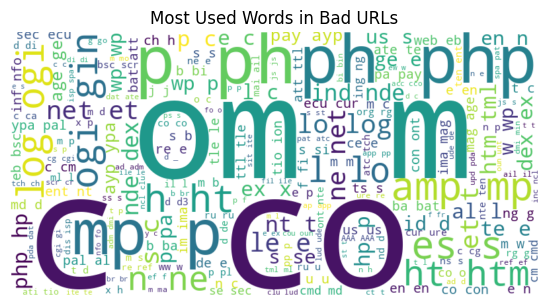

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from google.colab import files

# Ensure bad_sites and good_sites DataFrames are available
bad_sites = df[df.Label == 'bad']
good_sites = df[df.Label == 'good']

# Concatenate all lemmatized URL strings for bad sites
bad_urls_text = ' '.join(bad_sites['lemmatized_url_str'])

# Concatenate all lemmatized URL strings for good sites
good_urls_text = ' '.join(good_sites['lemmatized_url_str'])

# Generate Word Cloud for Bad URLs
wordcloud_bad = WordCloud(width=800, height=400, background_color='white').generate(bad_urls_text)

# Generate Word Cloud for Good URLs
wordcloud_good = WordCloud(width=800, height=400, background_color='white').generate(good_urls_text)

# Display the generated image:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_bad, interpolation='bilinear')
plt.axis('off')
plt.title('Most Used Words in Bad URLs')

plt.savefig('wordcloud_bad.png', dpi=300, bbox_inches='tight')   # save image
plt.show()

files.download('wordcloud_bad.png')


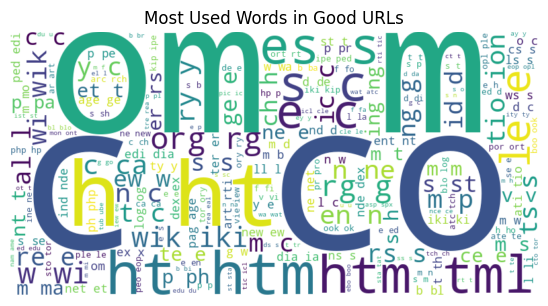

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_good, interpolation='bilinear')
plt.axis('off')
plt.title('Most Used Words in Good URLs')

plt.savefig('wordcloud_good.png', dpi=300, bbox_inches='tight')   # save image
plt.show()

files.download('wordcloud_good.png')

In [53]:
from sklearn.feature_selection import SelectKBest, chi2

# Ensure y_encoded is defined before use
y = df['Label']
y_encoded = y.map({'good': 1, 'bad': 0})

# Initialize SelectKBest with chi2 as the score function and k=10000 features
selector = SelectKBest(chi2, k=10000)

# Fit SelectKBest to the optimized TF-IDF matrix and the encoded target labels
selector.fit(tfidf_matrix_optimized, y_encoded)

# Transform the tfidf_matrix_optimized to get the selected features
tfidf_selected_features = selector.transform(tfidf_matrix_optimized)

print("Chi-Squared feature selection applied.")
print(f"Shape of TF-IDF matrix after feature selection: {tfidf_selected_features.shape}")

Chi-Squared feature selection applied.
Shape of TF-IDF matrix after feature selection: (549346, 10000)


In [54]:
from scipy.sparse import hstack, csr_matrix
import numpy as np

# Define numerical features (X) and target (y)
# Ensure 'parsed_url', 'lemmatized_url', 'tokenized_url', 'tokenized_url_no_stopwords', 'lemmatized_url_str'
# are dropped as they are intermediate or non-numerical and are not part of the final feature set.
# Keep 'URL' only if it's explicitly needed later for other purposes, but drop it for feature matrix.

X_numerical_df = df.drop(columns=[
    'Label', 'URL', 'parsed_url', 'lemmatized_url',
    'tokenized_url', 'tokenized_url_no_stopwords', 'lemmatized_url_str'
], axis=1)

# Select only numerical columns for X_numerical
numerical_cols = X_numerical_df.select_dtypes(include=np.number).columns
X_numerical = X_numerical_df[numerical_cols]

# Convert numerical features to sparse matrices to concatenate with TF-IDF
X_numerical_sparse = csr_matrix(X_numerical.values)

# Combine numerical features with the Chi-Squared selected TF-IDF features
X_combined_final = hstack([X_numerical_sparse, tfidf_selected_features])

print("Final combined feature matrix created using Chi-Squared selected TF-IDF features.")
print(f"Shape of X_combined_final: {X_combined_final.shape}")

Final combined feature matrix created using Chi-Squared selected TF-IDF features.
Shape of X_combined_final: (549346, 10074)


In [55]:
from sklearn.model_selection import train_test_split

# Split the combined feature set and encoded target labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Dataset split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset split into training and testing sets.
Shape of X_train: (439476, 10074)
Shape of X_test: (109870, 10074)
Shape of y_train: (439476,)
Shape of y_test: (109870,)


SGD Classifier

In [56]:
from sklearn.linear_model import SGDClassifier

# Initialize SGDClassifier model
sgd_classifier = SGDClassifier(
    loss='log_loss',  # For logistic regression
    penalty='l2',     # Regularization type
    max_iter=1000,    # Maximum number of passes over the training data
    tol=1e-3,         # Tolerance for stopping criterion
    random_state=42   # For reproducibility
)

# Fit the SGDClassifier model to the training data
sgd_classifier.fit(X_train, y_train)

print("SGDClassifier model trained successfully.")

SGDClassifier model trained successfully.


In [57]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions on the test set
y_pred = sgd_classifier.predict(X_test)

print("Model evaluation metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate and display the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

Model evaluation metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79     31285
           1       0.89      0.97      0.93     78585

    accuracy                           0.89    109870
   macro avg       0.90      0.84      0.86    109870
weighted avg       0.90      0.89      0.89    109870


Confusion Matrix:
[[21823  9462]
 [ 2104 76481]]

Accuracy Score: 0.8947


Model evaluation metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79     31285
           1       0.89      0.97      0.93     78585

    accuracy                           0.89    109870
   macro avg       0.90      0.84      0.86    109870
weighted avg       0.90      0.89      0.89    109870


Accuracy Score: 0.8947

Confusion Matrix:


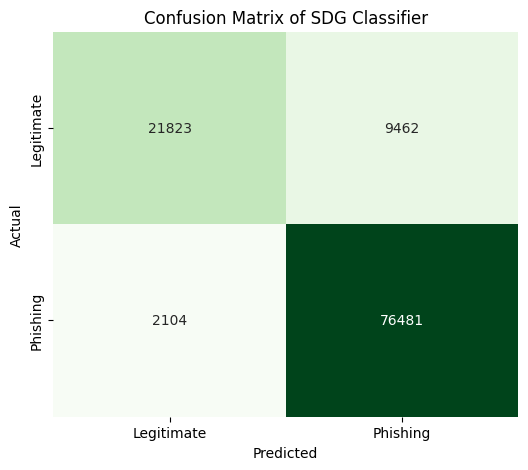

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import files

# 1. Make predictions
y_pred = sgd_classifier.predict(X_test)

# 2. Print Text Metrics
print("Model evaluation metrics:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# 3. Plot Confusion Matrix in Green
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# cmap='Greens' sets the color to green
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SDG Classifier')

plt.savefig('matrixSDG.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixSDG.png')

In [59]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize LinearSVC model
linear_svc_model = LinearSVC(random_state=42, max_iter=1000, dual=False) # dual=False for sparse matrices

# Fit the LinearSVC model to the training data
linear_svc_model.fit(X_train, y_train)

print("LinearSVC model trained successfully.")

# Make predictions on the test set
y_pred_svc = linear_svc_model.predict(X_test)

print("\nLinearSVC Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

# Calculate and display the accuracy score
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"\nAccuracy Score: {accuracy_svc:.4f}")

LinearSVC model trained successfully.

LinearSVC Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     31285
           1       0.96      0.98      0.97     78585

    accuracy                           0.96    109870
   macro avg       0.96      0.94      0.95    109870
weighted avg       0.96      0.96      0.96    109870


Confusion Matrix:
[[28008  3277]
 [ 1371 77214]]

Accuracy Score: 0.9577


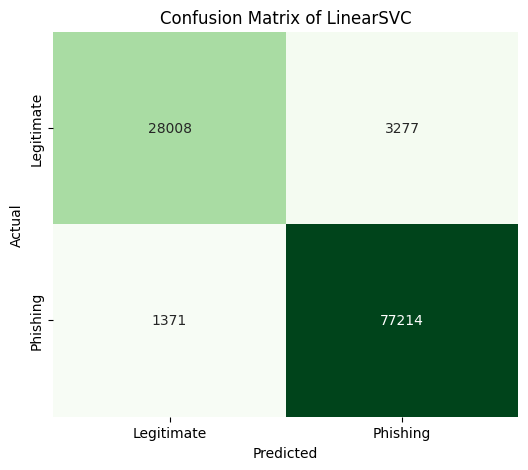

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
from google.colab import files
cm_svc = confusion_matrix(y_test, y_pred_svc)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LinearSVC')

plt.savefig('matrixLinearSVC.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixLinearSVC.png')


In [61]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize MultinomialNB model
multinomial_nb_model = MultinomialNB()

# Fit the MultinomialNB model to the training data
multinomial_nb_model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

# Make predictions on the test set
y_pred_mnb = multinomial_nb_model.predict(X_test)

print("\nMultinomial Naive Bayes Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mnb))

# Calculate and display the accuracy score
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"\nAccuracy Score: {accuracy_mnb:.4f}")

Multinomial Naive Bayes model trained successfully.

Multinomial Naive Bayes Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.62      0.69     31285
           1       0.86      0.93      0.89     78585

    accuracy                           0.84    109870
   macro avg       0.82      0.78      0.79    109870
weighted avg       0.84      0.84      0.84    109870


Confusion Matrix:
[[19445 11840]
 [ 5348 73237]]

Accuracy Score: 0.8436


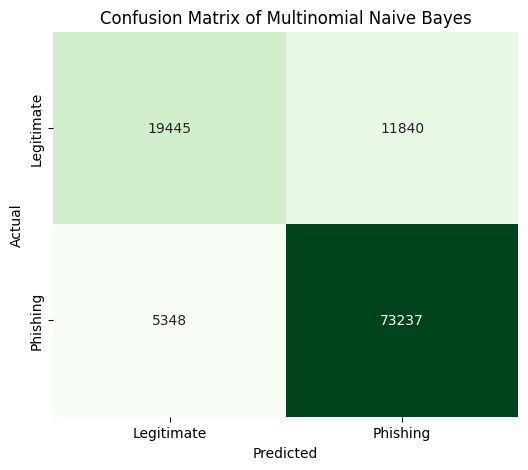

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
from google.colab import files
cm_mnb = confusion_matrix(y_test, y_pred_mnb)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Multinomial Naive Bayes')

plt.savefig('matrixMultinomialNaiveBayes.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixMultinomialNaiveBayes.png')

In [63]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize BernoulliNB model
bernoulli_nb_model = BernoulliNB()

# Fit the BernoulliNB model to the training data
bernoulli_nb_model.fit(X_train, y_train)

print("Bernoulli Naive Bayes model trained successfully.")

# Make predictions on the test set
y_pred_bnb = bernoulli_nb_model.predict(X_test)

print("\nBernoulli Naive Bayes Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bnb))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bnb))

# Calculate and display the accuracy score
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(f"\nAccuracy Score: {accuracy_bnb:.4f}")

Bernoulli Naive Bayes model trained successfully.

Bernoulli Naive Bayes Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     31285
           1       0.91      0.98      0.94     78585

    accuracy                           0.92    109870
   macro avg       0.92      0.87      0.89    109870
weighted avg       0.92      0.92      0.91    109870


Confusion Matrix:
[[23759  7526]
 [ 1741 76844]]

Accuracy Score: 0.9157


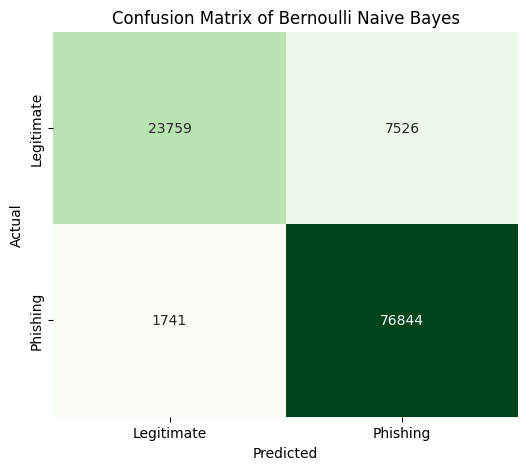

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
from google.colab import files
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Bernoulli Naive Bayes')

plt.savefig('matrixBernoulliNaiveBayes.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixBernoulliNaiveBayes.png')

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize DecisionTreeClassifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Fit the DecisionTreeClassifier model to the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

print("\nDecision Tree Classifier Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Calculate and display the accuracy score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy Score: {accuracy_dt:.4f}")

Decision Tree Classifier model trained successfully.

Decision Tree Classifier Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     31285
           1       0.97      0.97      0.97     78585

    accuracy                           0.96    109870
   macro avg       0.95      0.95      0.95    109870
weighted avg       0.96      0.96      0.96    109870


Confusion Matrix:
[[29322  1963]
 [ 2669 75916]]

Accuracy Score: 0.9578


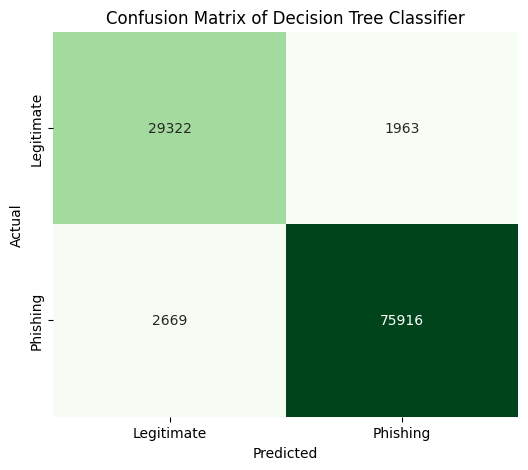

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
from google.colab import files
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Decision Tree Classifier')

plt.savefig('matrixDecisionTree.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixDecisionTree.png')

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize RandomForestClassifier model with specified parameters
# n_estimators=100 is a common starting point, and random_state for reproducibility
# Consider adjusting n_jobs=-1 for parallel processing if resources allow
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the RandomForestClassifier model to the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

print("\nRandom Forest Classifier Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Calculate and display the accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy Score: {accuracy_rf:.4f}")

Random Forest Classifier model trained successfully.

Random Forest Classifier Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     31285
           1       0.98      0.99      0.99     78585

    accuracy                           0.98    109870
   macro avg       0.98      0.97      0.97    109870
weighted avg       0.98      0.98      0.98    109870


Confusion Matrix:
[[29609  1676]
 [  696 77889]]

Accuracy Score: 0.9784


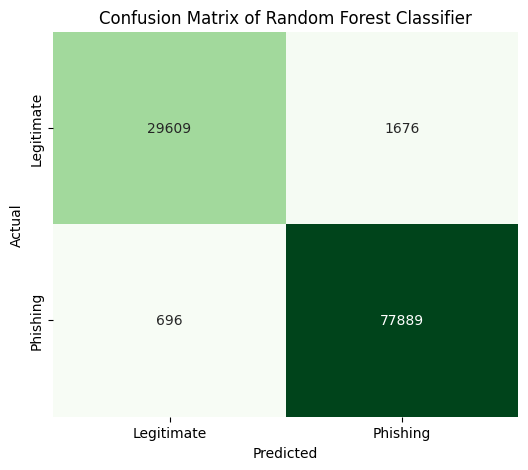

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
from google.colab import files
# Calculate Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Random Forest Classifier')

plt.savefig('matrixRandomForest.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixRandomForest.png')

Training XGBoost Classifier model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:41:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier model trained successfully.

XGBoost Classifier Model Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     31285
           1       0.95      0.98      0.97     78585

    accuracy                           0.95    109870
   macro avg       0.95      0.93      0.94    109870
weighted avg       0.95      0.95      0.95    109870


Confusion Matrix:
[[27259  4026]
 [ 1217 77368]]

Accuracy Score: 0.9523


<Figure size 800x600 with 0 Axes>

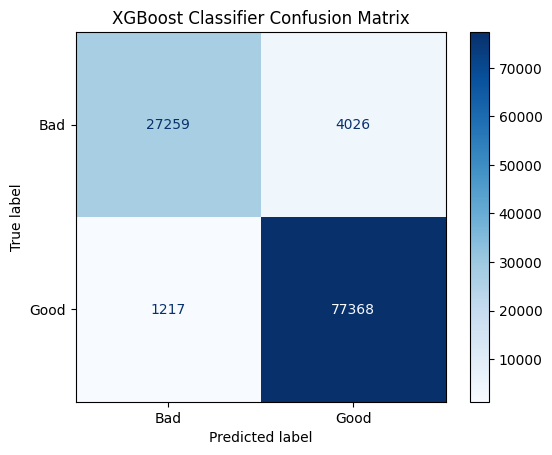

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import files

# Initialize XGBClassifier model
# Using tree_method='hist' for better performance on large datasets, and enabling parallel processing
xgb_classifier_model = xgb.XGBClassifier(
    objective='binary:logistic', # Binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for deprecated parameter
    n_estimators=100,            # Number of boosting rounds
    random_state=42,             # For reproducibility
    n_jobs=-1,                   # Use all available CPU cores
    tree_method='hist'           # Use histogram-based algorithm for better performance with sparse data
)

# Fit the XGBClassifier model to the training data
print("Training XGBoost Classifier model...")
xgb_classifier_model.fit(X_train, y_train)

print("XGBoost Classifier model trained successfully.")

# Make predictions on the test set
y_pred_xgb = xgb_classifier_model.predict(X_test)

print("\nXGBoost Classifier Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Compute and display the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

# Calculate and display the accuracy score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy Score: {accuracy_xgb:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Bad', 'Good']).plot(cmap=plt.cm.Blues)
plt.title('XGBoost Classifier Confusion Matrix')

plt.savefig('matrixXGBoost.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixXGBoost.png')

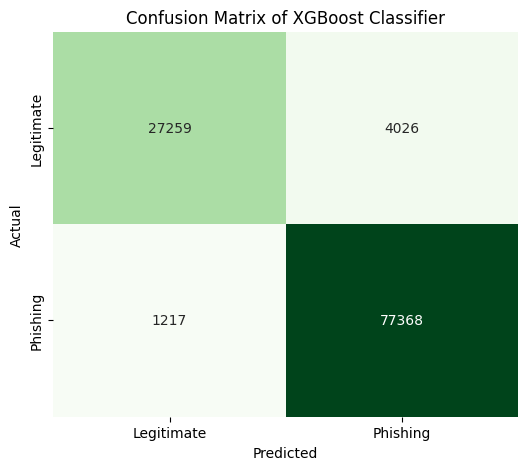

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
from google.colab import files
# Calculate Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of XGBoost Classifier')
plt.savefig('matrixXGBoost2.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixXGBoost2.png')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import files

# Initialize KNeighborsClassifier model
# n_neighbors is set to a common value (e.g., 5). This can be tuned.
# For large, sparse datasets, KNN can be very slow and memory intensive.
# The default algorithm 'auto' should handle sparse matrices.
print("Initializing KNeighborsClassifier...")
knn_classifier_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Fit the KNeighborsClassifier model to the training data
print("Training KNeighborsClassifier model... This may take a while due to the dataset size and dimensionality.")
knn_classifier_model.fit(X_train, y_train)

print("KNeighborsClassifier model trained successfully.")

# Make predictions on the test set
y_pred_knn = knn_classifier_model.predict(X_test)

print("\nKNeighborsClassifier Model Evaluation Metrics:")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Compute and display the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:")
print(cm_knn)

# Calculate and display the accuracy score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAccuracy Score: {accuracy_knn:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Bad', 'Good']).plot(cmap=plt.cm.Blues)
plt.title('KNeighborsClassifier Confusion Matrix')

plt.savefig('matrixKNN.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixKNN.png')

Initializing KNeighborsClassifier...
Training KNeighborsClassifier model... This may take a while due to the dataset size and dimensionality.
KNeighborsClassifier model trained successfully.


In [ ]:
from google.colab import files
# Calculate Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of KNeighborsClassifier')

plt.savefig('matrixKNN2.png', dpi=300, bbox_inches='tight')
plt.show()

files.download('matrixKNN2.png')

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize Tokenizer
# num_words can be specified to limit the vocabulary size, but for now, we'll use all words.
tokenizer = Tokenizer()

# Fit the tokenizer on the lemmatized_url_str column
tokenizer.fit_on_texts(df['lemmatized_url_str'])

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['lemmatized_url_str'])

# Pad sequences to a uniform length (e.g., 100)
max_sequence_length = 100
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

print("Text data processed for LSTM.")
print(f"Shape of padded sequences: {padded_sequences.shape}")

# Print a sample of the word index
print("\nSample Word Index (first 10 items):")
# Convert dict_items to a list to slice
sample_word_index = list(tokenizer.word_index.items())[:10]
for word, index in sample_word_index:
    print(f"'{word}': {index}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get vocabulary size from tokenizer
vocabulary_size = len(tokenizer.word_index) + 1
embedding_dim = 128 # You can adjust this

# Split the padded sequences into training and testing sets for LSTM
# Using the same random_state and stratify for consistency with previous splits
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    padded_sequences, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("LSTM data split into training and testing sets.")
print(f"Shape of X_train_lstm: {X_train_lstm.shape}")
print(f"Shape of X_test_lstm: {X_test_lstm.shape}")

# Define the LSTM model architecture
lstm_model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_sequence_length),
    SpatialDropout1D(0.2), # Dropout to prevent overfitting
    LSTM(128, dropout=0.2, recurrent_dropout=0.2), # LSTM layer with dropout
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM model defined and compiled.")
lstm_model.summary()

# Train the LSTM model
print("\nTraining LSTM model...")
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10, # Reduced epochs for demonstration, can be increased
    batch_size=64,
    validation_split=0.1, # Use a small portion of training data for validation
    verbose=1
)

print("LSTM model trained successfully.")

# Evaluate the LSTM model
loss, accuracy_lstm = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\nLSTM Model Test Accuracy: {accuracy_lstm:.4f}")

# Make predictions on the test set
y_pred_lstm_prob = lstm_model.predict(X_test_lstm)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

print("\nLSTM Model Evaluation Metrics:")
# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm))

# Compute and display the confusion matrix
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
print("\nConfusion Matrix:")
print(cm_lstm)

# Plot Confusion Matrix with green colormap
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Bad', 'Good']).plot(cmap='Greens')
plt.title('LSTM Classifier Confusion Matrix')
plt.show()

In [ ]:
# Calculate Confusion Matrix
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LSTM Classifier')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D, Concatenate, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Data Preparation ---
# Initialize Tokenizer
max_features = 20000  # distinct words/tokens
max_len = 100         # max length of URL sequence
embedding_dim = 128   # Size of the vector space

tokenizer_conv = Tokenizer(num_words=max_features)
# Ensure df and y_encoded are available from your previous cells
tokenizer_conv.fit_on_texts(df['lemmatized_url_str'])
sequences_conv = tokenizer_conv.texts_to_sequences(df['lemmatized_url_str'])
X_conv = pad_sequences(sequences_conv, maxlen=max_len)
y_conv = y_encoded.values

# --- 2. Train/Test Split ---
X_train_conv, X_test_conv, y_train_conv, y_test_conv = train_test_split(
    X_conv, y_conv, test_size=0.2, random_state=42, stratify=y_conv
)

print(f"Conv1D Data Shapes: Train={X_train_conv.shape}, Test={X_test_conv.shape}")

# --- 3. Define Optimized Multi-Kernel Conv1D Model ---
# Using Functional API to allow parallel branches

input_layer = Input(shape=(max_len,))
# SpatialDropout1D drops entire 1D feature maps instead of individual elements, better for text
embedding_layer = Embedding(input_dim=max_features, output_dim=embedding_dim, input_length=max_len)(input_layer)
x = SpatialDropout1D(0.2)(embedding_layer)

# Parallel Conv1D branches to capture n-grams of different sizes
# Branch 1: Looks for pairs of words/tokens (2-grams)
conv_block_1 = Conv1D(filters=128, kernel_size=2, activation='relu')(x)
pool_1 = GlobalMaxPooling1D()(conv_block_1)

# Branch 2: Looks for triplets (3-grams)
conv_block_2 = Conv1D(filters=128, kernel_size=3, activation='relu')(x)
pool_2 = GlobalMaxPooling1D()(conv_block_2)

# Branch 3: Looks for 4-grams
conv_block_3 = Conv1D(filters=128, kernel_size=4, activation='relu')(x)
pool_3 = GlobalMaxPooling1D()(conv_block_3)

# Branch 4: Looks for 5-grams
conv_block_4 = Conv1D(filters=128, kernel_size=5, activation='relu')(x)
pool_4 = GlobalMaxPooling1D()(conv_block_4)

# Concatenate all features
merged = Concatenate()([pool_1, pool_2, pool_3, pool_4])

# Dense Layers for classification
dense_1 = Dense(128, activation='relu')(merged)
norm_1 = BatchNormalization()(dense_1) # Stabilizes learning
drop_1 = Dropout(0.5)(norm_1)

dense_2 = Dense(64, activation='relu')(drop_1)
drop_2 = Dropout(0.5)(dense_2)

output_layer = Dense(1, activation='sigmoid')(drop_2)

model_conv = Model(inputs=input_layer, outputs=output_layer)

model_conv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_conv.summary()

# --- 4. Callbacks for Optimization ---
# Stop training if validation loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
# Reduce learning rate if progress stalls
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001, verbose=1)

# --- 5. Train Model ---
history_conv = model_conv.fit(
    X_train_conv, y_train_conv,
    epochs=20, # Increased epochs, EarlyStopping will handle stopping
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# --- 6. Evaluation ---
y_pred_conv_prob = model_conv.predict(X_test_conv)
y_pred_conv = (y_pred_conv_prob > 0.5).astype(int)

# Metrics
print("\nOptimized Conv1D Classification Report:")
print(classification_report(y_test_conv, y_pred_conv))

# Confusion Matrix
cm_conv = confusion_matrix(y_test_conv, y_pred_conv)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_conv, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Optimized Conv1D Model')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Check if history exists
if 'history_conv' in locals():
    history = history_conv

    # Extract data
    acc = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Create Plot
    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r--o', label='Validation Accuracy')
    plt.title('Conv1D Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig('plotAccuracy.png', dpi=300, bbox_inches='tight')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-o', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--o', label='Validation Loss')
    plt.title('Conv1D Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('plotLoss.png', dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

    files.download('plotAccuracy.png')
    files.download('plotLoss.png')
else:
    print("Error: 'history_conv' not found. Make sure you have run the Conv1D training cell.")

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from google.colab import files

# --- 1. Gather Confusion Matrices ---
# (Assumes y_test/pred variables are defined. Using try-except for safety)

# 1. SGD Classifier
try: cm_sgd = confusion_matrix(y_test, y_pred)
except NameError: cm_sgd = [[0,0],[0,0]]

# 2. LinearSVC
try: cm_svc = confusion_matrix(y_test, y_pred_svc)
except NameError: cm_svc = [[0,0],[0,0]]

# 3. Multinomial NB
try: cm_mnb = confusion_matrix(y_test, y_pred_mnb)
except NameError: cm_mnb = [[0,0],[0,0]]

# 4. Bernoulli NB
try: cm_bnb = confusion_matrix(y_test, y_pred_bnb)
except NameError: cm_bnb = [[0,0],[0,0]]
try: cm_dt = confusion_matrix(y_test, y_pred_dt)
except NameError: cm_dt = [[0,0],[0,0]]

# 6. Random Forest
try: cm_rf = confusion_matrix(y_test, y_pred_rf)
except NameError: cm_rf = [[0,0],[0,0]]

# 7. XGBoost
try: cm_xgb = confusion_matrix(y_test, y_pred_xgb)
except NameError: cm_xgb = [[0,0],[0,0]]

# 8. KNN
try: cm_knn = confusion_matrix(y_test, y_pred_knn)
except NameError:
    print("Warning: y_pred_knn not found. Using placeholder.")
    cm_knn = [[0,0],[0,0]]

# 9. LSTM
try: cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
except NameError:
    print("Warning: LSTM variables not found. Using placeholder.")
    cm_lstm = [[0,0],[0,0]]

# 10. Conv1D (New)
try: cm_conv = confusion_matrix(y_test_conv, y_pred_conv)
except NameError:
    print("Warning: Conv1D variables not found. Using placeholder.")
    cm_conv = [[0,0],[0,0]]

# --- 2. Define the List of Models ---
models = [
    ("Confusion Matrix of SGDClassifier", cm_sgd),
    ("Confusion Matrix of LinearSVC", cm_svc),
    ("Confusion Matrix of Multinomial Naive Bayes", cm_mnb),
    ("Confusion Matrix of Bernoulli Naive Bayes", cm_bnb),
    ("Confusion Matrix of Decision Tree", cm_dt),
    ("Confusion Matrix of Random Forest", cm_rf),
    ("Confusion Matrix of XGBoost", cm_xgb),
    ("Confusion Matrix of KNeighbors", cm_knn),
    ("Confusion Matrix of LSTM", cm_lstm),
    ("Confusion Matrix of Conv1D", cm_conv)
]

# --- 3. Plotting Logic (4x3 Grid for 11 Models) ---
# We need 4 rows to fit 11 plots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
plt.suptitle('Confusion Matrices of All 11 Models', fontsize=24, y=0.99)

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(models):
        # Plot the model
        title, cm = models[i]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
        disp.plot(cmap='Greens', ax=ax, colorbar=False, values_format='d')

        # Styling
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
    else:
        # Hide any extra empty subplots (e.g., the 12th slot)
        ax.axis('off')

  # Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()
plt.savefig('confusionMatrix.png', dpi=300, bbox_inches='tight')
files.download('confusionMatrix.png')